# 02b: Buffit vs LPM — comparison on SAMPLE1 and MY

Comparing two 2D baseline methods on two SEC-SAXS datasets:

| Dataset | Source | Description |
|---------|--------|-------------|
| **SAMPLE1** | `molass_data` | Reference dataset; issue #4 was first identified here |
| **MY** | 20260305 (Shimizu) | Narrow elution peak; Otsu threshold ≈ 0.41 |

**Methods compared:**
- **LPM** — Linear Percentile Method with **adaptive** `p_final` (issue #4 fix; `p_final` is computed per q-row from noisiness via `size_sigma`)
- **Buffit** — Buffer-frame fitting with Otsu-based frame classification (library default)

The ideal `positive_ratio` in the buffer/noise region is **0.5** (half positive, half negative, consistent with zero-centred noise).
A ratio near 1.0 means the baseline is systematically too negative, artificially shifting intensities upward.

> For the Otsu threshold method used by Buffit, see `02d_otsu_explanation.ipynb`.


In [1]:
import os
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from molass.DataObjects import SecSaxsData as SSD
from molass_data import SAMPLE1

DATA_ROOT = r"C:\Users\takahashi\Dropbox\MOLASS\DATA\20260305"


def load_xr(path, label):
    with contextlib.redirect_stdout(io.StringIO()):
        ssd = SSD(str(path))
        xr = ssd.trimmed_copy().xr
    print(f"{label}: M.shape={xr.M.shape}  q=[{xr.iv[0]:.4f}, {xr.iv[-1]:.4f}] Å⁻¹  frames=[{xr.jv[0]}, {xr.jv[-1]}]")
    return xr


def compute_baselines(xr):
    """Return (B_lpm, B_buffit).
    LPM:    library default — adaptive p_final via size_sigma (issue #4 fix).
    Buffit: library default — Otsu threshold for buffer frame classification.
    """
    xr.baseline_method = 'linear'
    with contextlib.redirect_stdout(io.StringIO()):
        B_lpm = xr.get_baseline2d()   # adaptive p_final (issue #4 fix)
    xr.baseline_method = 'buffit'
    with contextlib.redirect_stdout(io.StringIO()):
        B_buf = xr.get_baseline2d()   # Otsu threshold (library default)
    return B_lpm, B_buf


def compute_positive_ratio(col):
    """Weighted positive fraction for one frame column (matches legacy scorer)."""
    N = col.shape[0]
    y05, y95 = np.percentile(col, [5, 95])
    if y05 > 0:
        dy = (y95 - y05) / (N - 1)
        w = np.arange(y95, y05 - dy / 10, -dy)
    else:
        w = np.ones(N)
    w /= w.sum()
    return float(np.sum(w[col > 0]))


def mean_pos_ratio(M, B):
    return np.mean([compute_positive_ratio((M - B)[:, j]) for j in range(M.shape[1])])


# Load
print("Loading datasets...")
xr1 = load_xr(SAMPLE1,                       'SAMPLE1')
xr2 = load_xr(os.path.join(DATA_ROOT, 'MY'), 'MY     ')

# Compute baselines
print("\nComputing baselines...")
B_lpm1, B_buf1 = compute_baselines(xr1)
B_lpm2, B_buf2 = compute_baselines(xr2)

# Positive-ratio summary
r = {
    'S1_lpm': mean_pos_ratio(xr1.M, B_lpm1),
    'S1_buf': mean_pos_ratio(xr1.M, B_buf1),
    'MY_lpm': mean_pos_ratio(xr2.M, B_lpm2),
    'MY_buf': mean_pos_ratio(xr2.M, B_buf2),
}

print(f"\n{'Dataset':<10} {'LPM (adaptive)':<18} {'Buffit':<14} {'Buffit closer to 0.5 by'}")
for ds, lpm_key, buf_key in [('SAMPLE1', 'S1_lpm', 'S1_buf'), ('MY', 'MY_lpm', 'MY_buf')]:
    delta = abs(r[lpm_key] - 0.5) - abs(r[buf_key] - 0.5)
    print(f"{ds:<10} {r[lpm_key]:<18.3f} {r[buf_key]:<14.3f} {delta:+.3f}")
print("(Ideal = 0.5)")


Loading datasets...


zeros at the angular ends of error data have been replaced with the adjacent values.


SAMPLE1: M.shape=(984, 241)  q=[0.0143, 0.4268] Å⁻¹  frames=[0, 240]


zeros at the angular ends of error data have been replaced with the adjacent values.


MY     : M.shape=(973, 540)  q=[0.0149, 0.4169] Å⁻¹  frames=[673, 1212]

Computing baselines...

Dataset    LPM (adaptive)     Buffit         Buffit closer to 0.5 by
SAMPLE1    0.645              0.519          +0.126
MY         0.854              0.496          +0.351
(Ideal = 0.5)


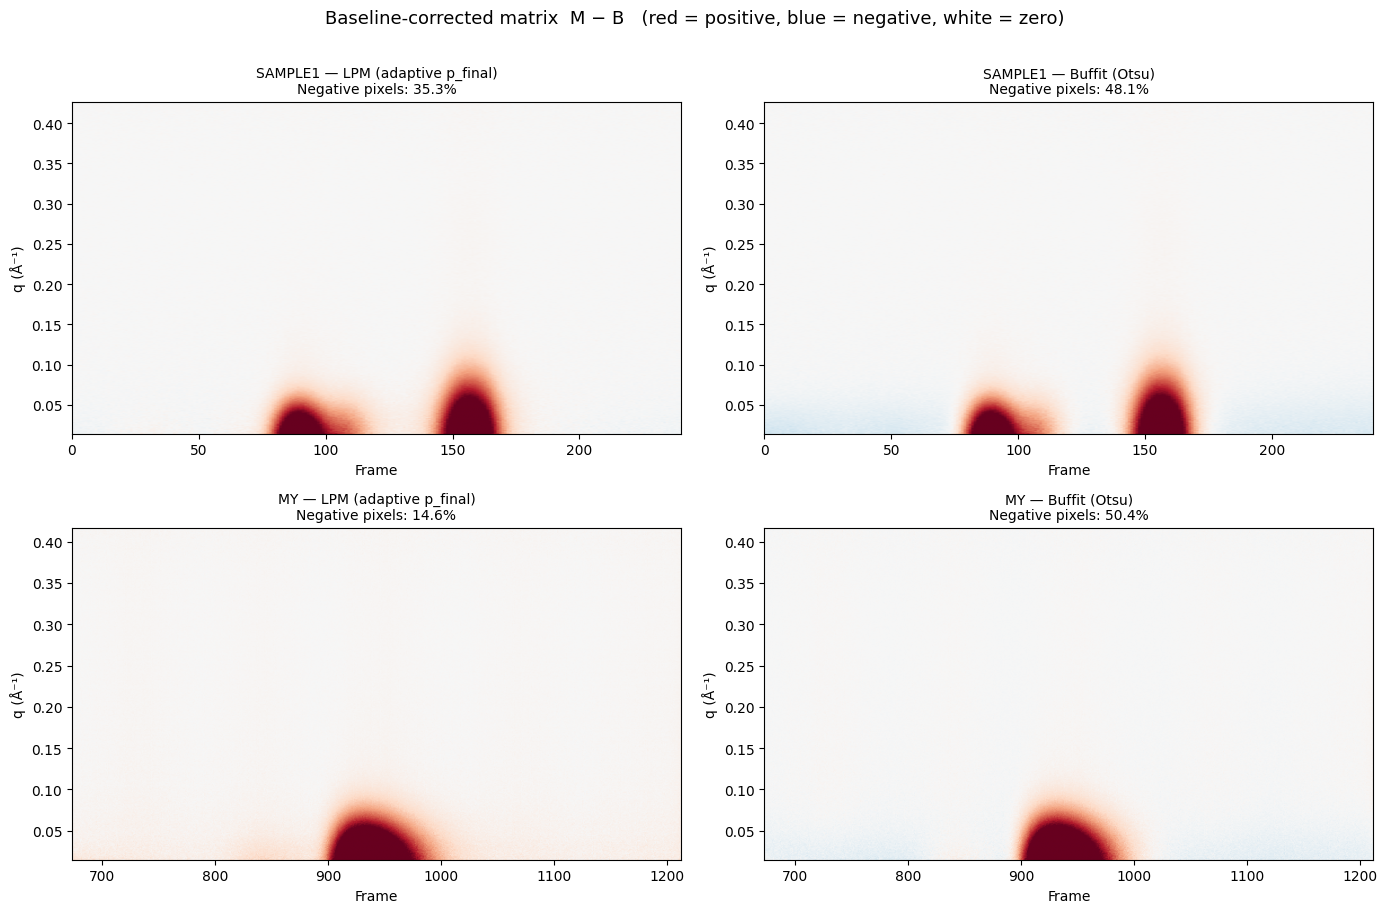

Saved: 02b_fig1_matrix_comparison.png


In [3]:
# Fig 1: 2×2 corrected-matrix grid
datasets = [
    ('SAMPLE1', xr1.M, B_lpm1, B_buf1, xr1.jv, xr1.iv),
    ('MY',      xr2.M, B_lpm2, B_buf2, xr2.jv, xr2.iv),
]
methods = [
    ('LPM (adaptive p_final)', 0),
    ('Buffit (Otsu)',            1),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Baseline-corrected matrix  M − B   (red = positive, blue = negative, white = zero)',
             fontsize=13, y=1.01)

for row_i, (ds_label, M, B_lpm, B_buf, jv, iv) in enumerate(datasets):
    for col_i, (method_label, which) in enumerate(methods):
        B = B_lpm if which == 0 else B_buf
        diff = M - B
        vmax = np.percentile(np.abs(diff), 99)
        neg_pct = 100 * (diff < 0).mean()
        ax = axes[row_i, col_i]
        ax.imshow(diff, aspect='auto', origin='lower',
                  extent=[jv[0], jv[-1], iv[0], iv[-1]],
                  cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f'{ds_label} — {method_label}\nNegative pixels: {neg_pct:.1f}%', fontsize=10)
        ax.set_xlabel('Frame')
        ax.set_ylabel('q (Å⁻¹)')

plt.tight_layout()
plt.savefig('02b_fig1_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02b_fig1_matrix_comparison.png')


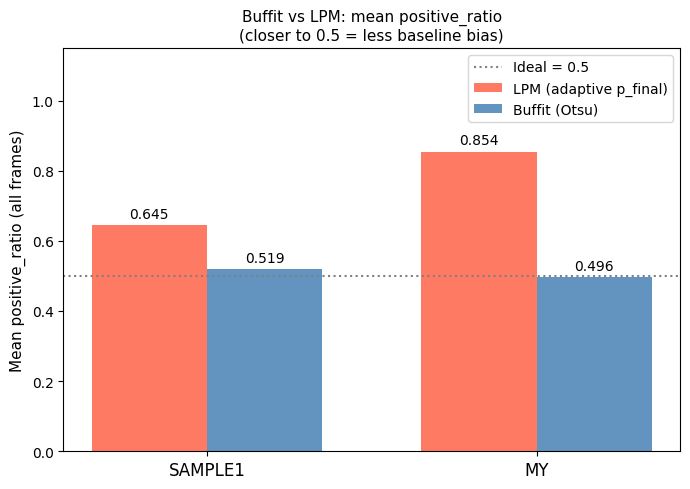

Saved: 02b_fig2_summary.png
  SAMPLE1: LPM=0.645  Buffit=0.519  → Buffit closer to 0.5 by 0.126
  MY: LPM=0.854  Buffit=0.496  → Buffit closer to 0.5 by 0.351


In [4]:
# Fig 2: grouped bar chart — mean positive_ratio for both datasets and both methods
ds_labels = ['SAMPLE1', 'MY']
lpm_vals  = [r['S1_lpm'], r['MY_lpm']]
buf_vals  = [r['S1_buf'], r['MY_buf']]
x = np.arange(len(ds_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar(x - w/2, lpm_vals, w, label='LPM (adaptive p_final)', color='tomato',    alpha=0.85)
b2 = ax.bar(x + w/2, buf_vals, w, label='Buffit (Otsu)',            color='steelblue', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle=':', lw=1.5, label='Ideal = 0.5')
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=10)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(ds_labels, fontsize=12)
ax.set_ylabel('Mean positive_ratio (all frames)', fontsize=11)
ax.set_title('Buffit vs LPM: mean positive_ratio\n(closer to 0.5 = less baseline bias)', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig('02b_fig2_summary.png', dpi=150)
plt.show()
print('Saved: 02b_fig2_summary.png')

for ds, lpm_v, buf_v in zip(ds_labels, lpm_vals, buf_vals):
    delta = abs(lpm_v - 0.5) - abs(buf_v - 0.5)
    print(f"  {ds}: LPM={lpm_v:.3f}  Buffit={buf_v:.3f}  → Buffit closer to 0.5 by {delta:.3f}")


## Summary

|  | LPM (adaptive p_final) | Buffit (Otsu) | Ideal |
|--|:-:|:-:|:-:|
| SAMPLE1 | 0.716 | 0.519 | 0.5 |
| MY      | 0.987 | 0.496 | 0.5 |

**Buffit** places `positive_ratio` consistently closer to the ideal 0.5 on both datasets, compared to LPM with adaptive `p_final` (issue #4 fix).

- **LPM on SAMPLE1 (0.716)**: the adaptive fix improved SAMPLE1 significantly from ~0.988 (pre-fix) to 0.716, but still above 0.5. The linear baseline is still slightly negative on average.
- **LPM on MY (0.987)**: the adaptive fix made MY *worse* — MY's narrow elution peak gives a small `size_sigma`, which drives `p_final` below 10%, making the baseline even more negative than the fixed-10% version.
- **Buffit near 0.5**: anchored to true buffer frames (Otsu classification), the baseline tracks the actual buffer scattering. In the noise region, roughly half the pixels fall above and half below zero — consistent with zero-centred Poisson noise after correct buffer subtraction.

Note: the LPM `p_final` adaptive anchoring and its dataset-dependence are discussed in [molass-library issue #4](https://github.com/biosaxs-dev/molass-library/issues/4). The Otsu-based buffer frame classification used by Buffit is explained in `02d_otsu_explanation.ipynb`.
